In [1]:
import os

# Step 1: Dekho folder ka naam kya hai
print(os.listdir("/kaggle/input/"))

['datasets']


In [2]:
# Step 2: Apna actual folder name yahan replace karo
print(os.listdir("/kaggle/input/datasets/"))

['binteadam']


In [3]:
# Step 3: binteadam ke andar kya hai
print(os.listdir("/kaggle/input/datasets/binteadam/"))

['liver-tumour']


In [4]:
# Step 4: liver-tumour ke andar kya hai
print(os.listdir("/kaggle/input/datasets/binteadam/liver-tumour/"))

['segmentations_reduced', 'volumes_reduced']


In [5]:
import os

data_path = "/kaggle/input/datasets/binteadam/liver-tumour/"

print("Segmentations:", os.listdir(data_path + "segmentations_reduced/"))
print("Volumes:", os.listdir(data_path + "volumes_reduced/"))

Segmentations: ['segmentation-100.nii', 'segmentation-36.nii', 'segmentation-96.nii', 'segmentation-4.nii', 'segmentation-8.nii', 'segmentation-97.nii', 'segmentation-101.nii', 'segmentation-48.nii', 'segmentation-95.nii', 'segmentation-114.nii', 'segmentation-70.nii', 'segmentation-65.nii', 'segmentation-85.nii', 'segmentation-82.nii', 'segmentation-58.nii', 'segmentation-125.nii', 'segmentation-90.nii', 'segmentation-54.nii', 'segmentation-68.nii', 'segmentation-52.nii', 'segmentation-89.nii', 'segmentation-63.nii', 'segmentation-112.nii', 'segmentation-11.nii', 'segmentation-111.nii', 'segmentation-130.nii', 'segmentation-127.nii', 'segmentation-117.nii', 'segmentation-17.nii', 'segmentation-84.nii', 'segmentation-105.nii', 'segmentation-35.nii', 'segmentation-6.nii', 'segmentation-129.nii', 'segmentation-75.nii', 'segmentation-128.nii', 'segmentation-34.nii', 'segmentation-93.nii']
Volumes: ['volume-100.nii', 'volume-34.nii', 'volume-54.nii', 'volume-8.nii', 'volume-63.nii', 'volum

In [6]:
%%writefile /kaggle/working/main.py
"""
AC-Net: Attention Connect Network for Liver Tumor Segmentation
Based on: Shao et al., 2024 — Technology in Cancer Research & Treatment
Dataset: LiTS (Liver Tumor Segmentation Challenge)
"""

import os
import gc
import time
import random
import warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from scipy.ndimage import distance_transform_edt
import csv

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════
#  MEMORY REDUCTION SETTINGS
# ════════════════════════════════════════════════════════════
IMG_SIZE_OVERRIDE        = 128
MAX_SLICES_PER_VOL_OVERRIDE = 15


# ─── CONFIGURATION ────────────────────────────────────────────────
class CFG:
    VOLUME_DIR   = 'archive (1)/dataset/volumes'
    SEG_DIR      = 'archive (1)/dataset/segmentations'
    SAVE_DIR     = './'
    MODEL_PATH   = './best_model.pth'

    IMG_SIZE     = IMG_SIZE_OVERRIDE
    IN_CHANNELS  = 1
    NUM_CLASSES  = 3

    HU_MIN       = -150
    HU_MAX       = 250

    MIN_LIVER_PIXELS  = 200
    MIN_TUMOR_PIXELS  = 10
    TUMOR_SLICE_RATIO = 0.5
    MAX_SLICES_PER_VOL = MAX_SLICES_PER_VOL_OVERRIDE

    # ── SIRF TRAIN / TEST ──────────────────────────────────────────
    TRAIN_RATIO  = 0.80   # val hataya
    TEST_RATIO   = 0.20
    SEED         = 42

    BATCH_SIZE   = 4
    NUM_EPOCHS   = 50
    LR           = 0.002
    MOMENTUM     = 0.9
    NUM_WORKERS  = 2

    VTM_HEADS    = 8
    VTM_LAYERS   = 1
    USE_MULTI_GPU = True

    # ── WARMUP ─────────────────────────────────────────────────────
    WARMUP_EPOCHS = 5


# ─── REPRODUCIBILITY ──────────────────────────────────────────────
def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()


# ─── DEVICE ───────────────────────────────────────────────────────
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f'🖥️  Device       : {device}')
        print(f'🎮  GPU count    : {torch.cuda.device_count()}')
        for i in range(torch.cuda.device_count()):
            mem = torch.cuda.get_device_properties(i).total_memory / 1e9
            print(f'   GPU {i}: {torch.cuda.get_device_name(i)} — {mem:.1f} GB')
        _test_tensor = torch.zeros(1).to(device)
        print(f'✅ GPU tensor test passed — device: {_test_tensor.device}')
        del _test_tensor
    else:
        print('⚠️  GPU NOT FOUND! Training will be very slow on CPU.')
        device = torch.device('cpu')
    print(f'📁  Volume dir  : {CFG.VOLUME_DIR}')
    print(f'📁  Seg dir     : {CFG.SEG_DIR}')
    return device


# ══════════════════════════════════════════════════════════
#  AXIAL ATTENTION MODULE (AAM)
# ══════════════════════════════════════════════════════════

class GatedAxialAttention(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=8, axis='height'):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.num_heads    = num_heads
        self.head_dim     = out_channels // num_heads
        self.axis         = axis

        self.q_conv = nn.Conv1d(in_channels, out_channels, 1, bias=False)
        self.k_conv = nn.Conv1d(in_channels, out_channels, 1, bias=False)
        self.v_conv = nn.Conv1d(in_channels, out_channels, 1, bias=False)

        self.GQ  = nn.Parameter(torch.ones(1, num_heads, 1, 1))
        self.GK  = nn.Parameter(torch.ones(1, num_heads, 1, 1))
        self.GV1 = nn.Parameter(torch.ones(1, num_heads, 1, 1))
        self.GV2 = nn.Parameter(torch.zeros(1, num_heads, 1, 1))

        self.out_conv = nn.Conv1d(out_channels, out_channels, 1, bias=False)
        self.bn       = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x):
        B, C, H, W = x.shape
        if self.axis == 'height':
            x_t = x.permute(0, 3, 1, 2).reshape(B * W, C, H)
            L = H
        else:
            x_t = x.permute(0, 2, 1, 3).reshape(B * H, C, W)
            L = W

        q = self.q_conv(x_t)
        k = self.k_conv(x_t)
        v = self.v_conv(x_t)

        BW = q.shape[0]
        q = q.view(BW, self.num_heads, self.head_dim, L)
        k = k.view(BW, self.num_heads, self.head_dim, L)
        v = v.view(BW, self.num_heads, self.head_dim, L)

        GQ = self.GQ.expand(BW, -1, -1, -1)
        GK = self.GK.expand(BW, -1, -1, -1)
        q_g = GQ * q
        k_g = GK * k

        scale = self.head_dim ** -0.5
        attn  = torch.matmul(q_g.permute(0,1,3,2), k_g) * scale
        attn  = F.softmax(attn, dim=-1)

        GV1 = self.GV1.expand(BW, -1, -1, -1)
        GV2 = self.GV2.expand(BW, -1, -1, -1)
        v_g = GV1 * v + GV2
        out = torch.matmul(v_g, attn.permute(0,1,3,2))
        out = out.reshape(BW, self.out_channels, L)
        out = self.out_conv(out)

        if self.axis == 'height':
            out = out.reshape(B, W, self.out_channels, H).permute(0, 2, 3, 1)
        else:
            out = out.reshape(B, H, self.out_channels, W).permute(0, 2, 1, 3)

        out = self.relu(self.bn(out))
        return out


class AxialAttentionModule(nn.Module):
    def __init__(self, in_channels, num_heads=8):
        super().__init__()
        self.conv_in   = nn.Conv2d(in_channels, in_channels, 1, bias=False)
        self.bn_in     = nn.BatchNorm2d(in_channels)
        self.aa_height = GatedAxialAttention(in_channels, in_channels, num_heads, axis='height')
        self.aa_width  = GatedAxialAttention(in_channels, in_channels, num_heads, axis='width')
        self.conv_out  = nn.Conv2d(in_channels, in_channels, 1, bias=False)
        self.bn_out    = nn.BatchNorm2d(in_channels)
        self.relu      = nn.ReLU(inplace=True)

    def forward(self, fm1, fm2):
        if fm1.shape != fm2.shape:
            fm2 = F.interpolate(fm2, size=fm1.shape[2:], mode='bilinear', align_corners=False)
        x = self.relu(self.bn_in(self.conv_in(fm1)))
        x = self.aa_height(x)
        x = self.aa_width(x)
        x = self.relu(self.bn_out(self.conv_out(x)))
        return torch.cat([x, fm2], dim=1)


# ══════════════════════════════════════════════════════════
#  VISION TRANSFORMER MODULE (VTM)
# ══════════════════════════════════════════════════════════

class VisionTransformerModule(nn.Module):
    def __init__(self, in_channels, feature_size, num_heads=8, mlp_ratio=4, num_layers=1):
        super().__init__()
        self.in_channels  = in_channels
        self.feature_size = feature_size
        self.num_patches  = feature_size * feature_size
        self.embed_dim    = in_channels

        self.patch_embed = nn.Linear(in_channels * 2, self.embed_dim)
        self.pos_embed   = nn.Parameter(torch.zeros(1, self.num_patches, self.embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=num_heads,
            dim_feedforward=self.embed_dim * mlp_ratio,
            dropout=0.1,
            activation='relu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(self.embed_dim)
        self.fcn  = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim),
            nn.GELU(),
            nn.Linear(self.embed_dim, self.embed_dim)
        )

    def forward(self, fm1, fm2):
        B, C, H, W = fm1.shape
        x = torch.cat([fm1, fm2], dim=1)
        x = x.view(B, 2*C, H*W).permute(0, 2, 1)
        x = self.patch_embed(x)

        num_patches = H * W
        if num_patches != self.num_patches:
            pos_embed = F.interpolate(
                self.pos_embed.permute(0, 2, 1).view(1, self.embed_dim, self.feature_size, self.feature_size),
                size=(H, W), mode='bilinear', align_corners=False
            ).view(1, self.embed_dim, num_patches).permute(0, 2, 1)
        else:
            pos_embed = self.pos_embed

        x  = x + pos_embed
        z0 = self.transformer(x)
        z0 = self.norm(z0)
        z1 = self.fcn(z0) + z0
        z  = z1.permute(0, 2, 1).view(B, self.embed_dim, H, W)
        return z


# ══════════════════════════════════════════════════════════
#  ENCODER / DECODER BLOCKS
# ══════════════════════════════════════════════════════════

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        dH = x2.shape[2] - x1.shape[2]
        dW = x2.shape[3] - x1.shape[3]
        x1 = F.pad(x1, [dW//2, dW-dW//2, dH//2, dH-dH//2])
        return self.conv(torch.cat([x2, x1], dim=1))


# ══════════════════════════════════════════════════════════
#  COMPLETE AC-NET
# ══════════════════════════════════════════════════════════

class ACNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, base_ch=64,
                 img_size=256, vtm_heads=8, vtm_layers=1):
        super().__init__()
        self.enc1       = DoubleConv(in_channels, base_ch)
        self.enc2       = Down(base_ch,     base_ch*2)
        self.enc3       = Down(base_ch*2,   base_ch*4)
        self.enc4       = Down(base_ch*4,   base_ch*8)
        self.bottleneck = Down(base_ch*8,   base_ch*16)

        vtm_ch = base_ch * 8
        vtm_sz = img_size // 8
        self.vtm = VisionTransformerModule(
            in_channels=vtm_ch, feature_size=vtm_sz,
            num_heads=vtm_heads, num_layers=vtm_layers)
        self.vtm_proj = nn.Sequential(
            nn.Conv2d(vtm_ch, vtm_ch, 1, bias=False),
            nn.BatchNorm2d(vtm_ch), nn.ReLU(inplace=True))

        aam_ch = base_ch * 2
        aam_nheads = 8 if aam_ch >= 8 else aam_ch
        self.aam = AxialAttentionModule(aam_ch, num_heads=aam_nheads)
        self.aam_proj = nn.Sequential(
            nn.Conv2d(aam_ch * 2, aam_ch, 1, bias=False),
            nn.BatchNorm2d(aam_ch), nn.ReLU(inplace=True))

        self.up4      = Up(base_ch*16, base_ch*8)
        self.up3      = Up(base_ch*8,  base_ch*4)
        self.up2      = Up(base_ch*4,  base_ch*2)
        self.up1      = Up(base_ch*2,  base_ch)
        self.out_conv = nn.Conv2d(base_ch, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        bn = self.bottleneck(e4)

        d4       = self.up4(bn, e4)
        vtm_out  = self.vtm_proj(self.vtm(e4, d4))
        d4_fused = d4 + vtm_out

        d3       = self.up3(d4_fused, e3)
        d2       = self.up2(d3, e2)
        aam_out  = self.aam_proj(self.aam(e2, d2))
        d2_fused = d2 + aam_out

        d1  = self.up1(d2_fused, e1)
        return self.out_conv(d1)


# ══════════════════════════════════════════════════════════
#  LOSS FUNCTION
# ══════════════════════════════════════════════════════════

class ACNetLoss(nn.Module):
    def __init__(self, num_classes=3, batch_size=4):
        super().__init__()
        self.num_classes = num_classes
        self.batch_size  = batch_size
        self.bce_logits  = nn.BCEWithLogitsLoss()
        self.ce          = nn.CrossEntropyLoss()

    def dice_score(self, pred_soft, target_onehot, smooth=1e-6):
        dice = 0.0
        for c in range(1, self.num_classes):
            p = pred_soft[:, c].contiguous().view(-1)
            t = target_onehot[:, c].contiguous().view(-1).float()
            intersection = (p * t).sum()
            dice += (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)
        return dice / (self.num_classes - 1)

    def forward(self, logits, target):
        B, C, H, W = logits.shape
        target_onehot = F.one_hot(target, num_classes=C).permute(0,3,1,2).float()
        loss1 = self.bce_logits(logits, target_onehot)
        ce_el = F.cross_entropy(logits, target, reduction='none')
        loss2 = torch.mean((1.0 - torch.exp(-ce_el)) * ce_el)
        pred_soft = F.softmax(logits, dim=1)
        dice = self.dice_score(pred_soft, target_onehot)
        total = 0.5 * (loss1 + loss2) - dice / (self.batch_size + 1)
        return total, loss1.item(), loss2.item(), dice.item()


# ══════════════════════════════════════════════════════════
#  DATASET  (IMPROVED AUGMENTATION)
# ══════════════════════════════════════════════════════════

class LiTSSliceDataset(Dataset):
    """2D slice extractor — improved augmentation pipeline."""

    def __init__(self, pairs, img_size=256, augment=False, mode='train'):
        self.img_size = img_size
        self.augment  = augment
        self.mode     = mode
        self.slices   = []

        print(f'⏳ Pre-loading {mode} volumes into RAM ({len(pairs)} volumes)...')
        for vol_path, seg_path in tqdm(pairs, desc=f'{mode} loading'):
            vol = nib.load(vol_path).get_fdata().astype(np.float32)
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            n_slices = seg.shape[2]
            slice_count = 0
            for s in range(n_slices):
                if slice_count >= CFG.MAX_SLICES_PER_VOL:
                    break
                seg_s = seg[:, :, s]
                if np.sum(seg_s >= 1) >= CFG.MIN_LIVER_PIXELS:
                    self.slices.append((vol[:, :, s].copy(), seg_s.copy()))
                    slice_count += 1
            del vol, seg
            gc.collect()

        print(f'   ✅ {mode}: {len(self.slices)} valid slices')

    def __len__(self): return len(self.slices)

    def _preprocess_volume(self, vol_slice):
        vol = np.clip(vol_slice, CFG.HU_MIN, CFG.HU_MAX)
        return ((vol - CFG.HU_MIN) / (CFG.HU_MAX - CFG.HU_MIN)).astype(np.float32)

    def _resize(self, img, seg):
        img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
        seg_t = torch.from_numpy(seg).unsqueeze(0).unsqueeze(0).float()
        img_r = F.interpolate(img_t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze()
        seg_r = F.interpolate(seg_t, size=(self.img_size, self.img_size),
                              mode='nearest').squeeze().long()
        return img_r, seg_r

    def _augment(self, img, seg):
        # 1. Horizontal flip
        if random.random() > 0.5:
            img = TF.hflip(img.unsqueeze(0)).squeeze(0)
            seg = TF.hflip(seg.unsqueeze(0)).squeeze(0)

        # 2. Vertical flip
        if random.random() > 0.5:
            img = TF.vflip(img.unsqueeze(0)).squeeze(0)
            seg = TF.vflip(seg.unsqueeze(0)).squeeze(0)

        # 3. Random rotation (wider range: -20 to +20)
        if random.random() > 0.5:
            angle = random.uniform(-20, 20)
            img = TF.rotate(img.unsqueeze(0), angle,
                            interpolation=TF.InterpolationMode.BILINEAR).squeeze(0)
            seg = TF.rotate(seg.unsqueeze(0).float(), angle,
                            interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()

        # 4. Brightness / contrast jitter
        if random.random() > 0.5:
            factor = random.uniform(0.75, 1.25)
            img = torch.clamp(img * factor, 0.0, 1.0)

        # 5. ✨ NEW: Gaussian noise (improves robustness)
        if random.random() > 0.5:
            noise = torch.randn_like(img) * random.uniform(0.01, 0.04)
            img = torch.clamp(img + noise, 0.0, 1.0)

        # 6. ✨ NEW: Random crop-and-resize (10% crop)
        if random.random() > 0.5:
            s = self.img_size
            crop_pct = random.uniform(0.85, 1.0)
            new_s = int(s * crop_pct)
            i = random.randint(0, s - new_s)
            j = random.randint(0, s - new_s)
            img = img[i:i+new_s, j:j+new_s].unsqueeze(0).unsqueeze(0)
            seg = seg[i:i+new_s, j:j+new_s].float().unsqueeze(0).unsqueeze(0)
            img = F.interpolate(img, size=(s, s), mode='bilinear', align_corners=False).squeeze()
            seg = F.interpolate(seg, size=(s, s), mode='nearest').squeeze().long()

        return img, seg

    def __getitem__(self, idx):
        vol_s, seg_s = self.slices[idx]
        vol_s = self._preprocess_volume(vol_s)
        img, seg = self._resize(vol_s, seg_s)
        if self.augment:
            img, seg = self._augment(img, seg)
        img = img.unsqueeze(0) if img.dim() == 2 else img
        return img.float(), seg.long()


# ══════════════════════════════════════════════════════════
#  EVALUATION METRICS
# ══════════════════════════════════════════════════════════

def compute_metrics(pred_mask, true_mask, class_id):
    pred_b = (pred_mask == class_id).astype(np.uint8)
    true_b = (true_mask == class_id).astype(np.uint8)
    TP = np.sum(pred_b & true_b)
    FP = np.sum(pred_b & ~true_b.astype(bool))
    FN = np.sum(~pred_b.astype(bool) & true_b)
    smooth = 1e-6
    dsc       = (2*TP + smooth) / (2*TP + FP + FN + smooth)
    jc        = (TP + smooth) / (TP + FP + FN + smooth)
    recall    = (TP + smooth) / (TP + FN + smooth)
    precision = (TP + smooth) / (TP + FP + smooth)
    hd = assd = 0.0
    if pred_b.sum() > 0 and true_b.sum() > 0:
        try:
            pred_dist = distance_transform_edt(~pred_b.astype(bool))
            true_dist = distance_transform_edt(~true_b.astype(bool))
            pred_surf = pred_b & np.roll(pred_b, 1, axis=0) ^ pred_b
            true_surf = true_b & np.roll(true_b, 1, axis=0) ^ true_b
            d_pt = pred_dist[true_surf.astype(bool)] if true_surf.sum() > 0 else np.array([0])
            d_tp = true_dist[pred_surf.astype(bool)] if pred_surf.sum() > 0 else np.array([0])
            hd   = max(d_pt.max() if len(d_pt) > 0 else 0,
                       d_tp.max() if len(d_tp) > 0 else 0)
            all_dists = np.concatenate([d_pt, d_tp])
            assd = all_dists.mean() if len(all_dists) > 0 else 0.0
        except Exception:
            hd, assd = 0.0, 0.0
    return {'DSC': dsc, 'JC': jc, 'Recall': recall,
            'Precision': precision, 'HD': hd, 'ASSD': assd}


@torch.no_grad()
def evaluate_model(model, dataloader, device, num_batches=None):
    model.eval()
    all_liver, all_tumor = [], []
    for i, (imgs, masks) in enumerate(tqdm(dataloader, desc='Evaluating', leave=False)):
        if num_batches and i >= num_batches:
            break
        logits = model(imgs.to(device))
        preds  = logits.argmax(dim=1).cpu().numpy()
        masks  = masks.numpy()
        for b in range(preds.shape[0]):
            all_liver.append(compute_metrics(preds[b], masks[b], class_id=1))
            all_tumor.append(compute_metrics(preds[b], masks[b], class_id=2))

    def avg(lst, key): return np.mean([d[key] for d in lst]) if lst else 0.0
    if not all_liver:
        dummy = {k: 0.0 for k in ['DSC','JC','Recall','Precision','HD','ASSD']}
        return dummy, dummy
    return ({k: avg(all_liver, k) for k in all_liver[0]},
            {k: avg(all_tumor, k) for k in all_tumor[0]})


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ══════════════════════════════════════════════════════════
#  WARMUP + COSINE SCHEDULER
# ══════════════════════════════════════════════════════════

class WarmupCosineScheduler(optim.lr_scheduler._LRScheduler):
    """Linear warmup then cosine annealing."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-5, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.eta_min       = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup_epochs:
            factor = (ep + 1) / self.warmup_epochs
        else:
            progress = (ep - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            factor = self.eta_min / self.base_lrs[0] + \
                     0.5 * (1 - self.eta_min / self.base_lrs[0]) * \
                     (1 + np.cos(np.pi * progress))
        return [base_lr * factor for base_lr in self.base_lrs]


# ══════════════════════════════════════════════════════════
#  DATASET LOADER  (TRAIN / TEST ONLY — no val)
# ══════════════════════════════════════════════════════════

def load_dataset():
    print('\n' + '='*60)
    print('📂 LOADING DATASET  (Train / Test split only)')
    print('='*60)

    volume_paths = sorted(Path(CFG.VOLUME_DIR).glob('*.nii'))
    seg_paths    = sorted(Path(CFG.SEG_DIR).glob('*.nii'))
    if not volume_paths:
        volume_paths = sorted(Path(CFG.VOLUME_DIR).glob('*.nii.gz'))
        seg_paths    = sorted(Path(CFG.SEG_DIR).glob('*.nii.gz'))

    print(f'📊 Total volumes   : {len(volume_paths)}')
    print(f'📊 Total seg masks : {len(seg_paths)}')

    pairs = []
    for vp in volume_paths:
        vid = ''.join(filter(str.isdigit, vp.stem))
        matched = [sp for sp in seg_paths if ''.join(filter(str.isdigit, sp.stem)) == vid]
        if matched:
            pairs.append((str(vp), str(matched[0])))

    print(f'✅ Matched pairs    : {len(pairs)}')
    if not pairs:
        raise RuntimeError('❌ No matched pairs found! Check dataset path.')

    # ── SIRF TRAIN / TEST  80 / 20 ────────────────────────────────
    indices = list(range(len(pairs)))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=CFG.TEST_RATIO,
        random_state=CFG.SEED
    )
    train_pairs = [pairs[i] for i in train_idx]
    test_pairs  = [pairs[i] for i in test_idx]

    print(f'\n📌 Patient-level split (no validation):')
    print(f'   Train : {len(train_pairs)} patients  ({CFG.TRAIN_RATIO*100:.0f}%)')
    print(f'   Test  : {len(test_pairs)} patients  ({CFG.TEST_RATIO*100:.0f}%)')

    return train_pairs, test_pairs


def train():
    device = setup_device()
    train_pairs, test_pairs = load_dataset()

    print('\n⏳ Building datasets...')
    train_ds = LiTSSliceDataset(train_pairs, img_size=CFG.IMG_SIZE, augment=True,  mode='train')
    test_ds  = LiTSSliceDataset(test_pairs,  img_size=CFG.IMG_SIZE, augment=False, mode='test')

    print(f'\n📊 Slice counts:')
    print(f'   Train : {len(train_ds):,}')
    print(f'   Test  : {len(test_ds):,}')

    train_dl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
    test_dl  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

    imgs, masks = next(iter(train_dl))
    print(f'\n✅ Sample batch:')
    print(f'   Images : {imgs.shape}  dtype={imgs.dtype}')
    print(f'   Masks  : {masks.shape} dtype={masks.dtype}')
    print(f'   Labels : {masks.unique().tolist()}')

    print('\n' + '='*60)
    print('🧠 BUILDING AC-NET MODEL')
    print('='*60)

    model = ACNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES,
                  img_size=CFG.IMG_SIZE, vtm_heads=CFG.VTM_HEADS, vtm_layers=CFG.VTM_LAYERS)

    if CFG.USE_MULTI_GPU and torch.cuda.device_count() > 1:
        print(f'🚀 Using {torch.cuda.device_count()} GPUs with DataParallel!')
        model = nn.DataParallel(model)

    model     = model.to(device)
    optimizer = optim.Adagrad(model.parameters(), lr=CFG.LR)
    scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=CFG.WARMUP_EPOCHS,
                                       total_epochs=CFG.NUM_EPOCHS, eta_min=1e-5)
    criterion = ACNetLoss(num_classes=CFG.NUM_CLASSES, batch_size=CFG.BATCH_SIZE)
    scaler    = torch.cuda.amp.GradScaler()
    USE_AMP   = torch.cuda.is_available()

    # Class-weighted CE for imbalance
    class_weights = torch.tensor([0.2, 1.0, 3.0]).to(device)
    weighted_ce   = nn.CrossEntropyLoss(weight=class_weights)

    print(f'📊 Total params   : {count_params(model):,}')
    print(f'⚡ AMP            : {"ENABLED" if USE_AMP else "DISABLED"}')
    print(f'🔥 Warmup epochs  : {CFG.WARMUP_EPOCHS}')
    print(f'✅ Class weights  : BG=0.2, Liver=1.0, Tumor=3.0')

    history = {'train_loss': [], 'train_dice': [], 'lr': []}
    best_train_dice = 0.0
    start_time = time.time()

    print('\n' + '='*60)
    print('🏋️  TRAINING AC-NET  (Train/Test only)')
    print('='*60)

    for epoch in range(1, CFG.NUM_EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        losses, dices = [], []

        for imgs, masks in tqdm(train_dl, desc=f'Epoch {epoch:02d}/{CFG.NUM_EPOCHS}', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(imgs)
                ac_loss, _, _, dice = criterion(logits, masks)
                wce_loss = weighted_ce(logits, masks)
                loss = ac_loss + 0.3 * wce_loss

            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            losses.append(loss.item())
            dices.append(dice)

        scheduler.step()
        t_loss = np.mean(losses)
        t_dice = np.mean(dices)
        cur_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - epoch_start

        history['train_loss'].append(t_loss)
        history['train_dice'].append(t_dice)
        history['lr'].append(cur_lr)

        star = ''
        if t_dice > best_train_dice:
            best_train_dice = t_dice
            model_state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save({'epoch': epoch, 'model_state_dict': model_state,
                        'best_train_dice': best_train_dice, 'history': history}, CFG.MODEL_PATH)
            star = ' ⭐ BEST'

        total_min = (time.time() - start_time) / 60
        print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | Loss:{t_loss:.4f} | '
              f'Dice:{t_dice:.4f} | LR:{cur_lr:.2e} | {elapsed:.1f}s | {total_min:.1f}min{star}')

        if epoch % 10 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    print(f'\n🎉 Training complete! Best Train Dice: {best_train_dice:.4f}')

    # ── FINAL TEST EVALUATION ─────────────────────────────────────
    print('\n' + '='*60)
    print('📊 FINAL TEST EVALUATION')
    print('='*60)
    ckpt = torch.load(CFG.MODEL_PATH, map_location=device, weights_only=False)
    best_model = ACNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES,
                       img_size=CFG.IMG_SIZE, vtm_heads=CFG.VTM_HEADS, vtm_layers=CFG.VTM_LAYERS)
    best_model.load_state_dict(ckpt['model_state_dict'])
    if CFG.USE_MULTI_GPU and torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
    best_model = best_model.to(device)

    liver_m, tumor_m = evaluate_model(best_model, test_dl, device)
    paper = {'DSC':0.90,'JC':0.82,'Recall':0.92,'Precision':0.89,'HD':11.96,'ASSD':4.59}
    mnames = ['DSC','JC','Recall','Precision','HD','ASSD']

    print(f'\n{"Metric":<12} {"Liver":>10} {"Tumor":>10} {"Paper":>10}')
    print('-'*45)
    for m in mnames:
        print(f'{m:<12} {liver_m[m]:>10.4f} {tumor_m[m]:>10.4f} {paper[m]:>10.2f}')


if __name__ == '__main__':
    train()


Writing /kaggle/working/main.py


In [7]:
import os
import gc
import sys
sys.path.insert(0, '/kaggle/working/')

from main import *

# ═══════════════════════════════════════════════════════════
#  IMPROVED v2 — 100 Epochs, AdamW, Warm Restarts
#
#  Problems pehle wale mein:
#   ❌ Adagrad  → LR ep50 par 8e-4 ho gaya (too slow)
#   ❌ Ek cosine cycle → plateau se nahi nikla
#   ❌ Train dice tracked WITH augmentation → misleading low
#
#  Fixes:
#   ✅ AdamW (LR=3e-4, weight_decay=1e-4) — stable convergence
#   ✅ CosineAnnealingWarmRestarts T0=25 → 3 restarts (25/50/75)
#   ✅ Warmup 10 epochs
#   ✅ MAX_SLICES_PER_VOL 15→20 (450→600 slices more data)
#   ✅ Har 10 epoch par true train eval (no augmentation)
#   ✅ 100 epochs
#   ✅ Augmentation probability thodi reduce (better train signal)
# ═══════════════════════════════════════════════════════════

class CFG_V2(CFG):
    VOLUME_DIR         = '/kaggle/input/datasets/binteadam/liver-tumour/volumes_reduced'
    SEG_DIR            = '/kaggle/input/datasets/binteadam/liver-tumour/segmentations_reduced'
    MODEL_PATH         = './best_model_v2.pth'

    # ── Core changes ─────────────────────────────────────────────
    NUM_EPOCHS         = 100
    BATCH_SIZE         = 4
    LR                 = 3e-4        # AdamW ke liye (Adagrad 1e-2 tha)
    WEIGHT_DECAY       = 1e-4
    WARMUP_EPOCHS      = 10          # 100 ep ke liye 10 better hai
    MAX_SLICES_PER_VOL = 20          # 15 se 20 → zyada training data
    NUM_WORKERS        = 2

    # ── Split ────────────────────────────────────────────────────
    TRAIN_RATIO  = 0.80
    TEST_RATIO   = 0.20

    # ── Warm restart period ──────────────────────────────────────
    # T0=25: restarts at ep 25, 50, 75 → plateau se bahar nikalte hain
    COSINE_T0    = 25
    COSINE_TMULT = 1   # har restart same length


# ══════════════════════════════════════════════════════════
#  DATASET WITH TUNED AUGMENTATION
#  (probability thodi kam → cleaner train signal)
# ══════════════════════════════════════════════════════════

class LiTSSliceDatasetV2(LiTSSliceDataset):
    """Same as base but augmentation probabilities tuned."""

    def _augment(self, img, seg):
        # 1. Horizontal flip  (50% → same)
        if random.random() > 0.5:
            img = TF.hflip(img.unsqueeze(0)).squeeze(0)
            seg = TF.hflip(seg.unsqueeze(0)).squeeze(0)

        # 2. Vertical flip  (50% → 30% — less aggressive)
        if random.random() > 0.7:
            img = TF.vflip(img.unsqueeze(0)).squeeze(0)
            seg = TF.vflip(seg.unsqueeze(0)).squeeze(0)

        # 3. Rotation  ±15° (was ±20°)
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            img = TF.rotate(img.unsqueeze(0), angle,
                            interpolation=TF.InterpolationMode.BILINEAR).squeeze(0)
            seg = TF.rotate(seg.unsqueeze(0).float(), angle,
                            interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()

        # 4. Brightness jitter  (was 0.75-1.25 → 0.85-1.15 tighter)
        if random.random() > 0.5:
            factor = random.uniform(0.85, 1.15)
            img = torch.clamp(img * factor, 0.0, 1.0)

        # 5. Gaussian noise  (same)
        if random.random() > 0.5:
            noise = torch.randn_like(img) * random.uniform(0.01, 0.03)
            img = torch.clamp(img + noise, 0.0, 1.0)

        # 6. Random crop-resize  (30% chance, was 50%)
        if random.random() > 0.7:
            s = self.img_size
            crop_pct = random.uniform(0.88, 1.0)
            new_s = int(s * crop_pct)
            i = random.randint(0, s - new_s)
            j = random.randint(0, s - new_s)
            img = img[i:i+new_s, j:j+new_s].unsqueeze(0).unsqueeze(0)
            seg = seg[i:i+new_s, j:j+new_s].float().unsqueeze(0).unsqueeze(0)
            img = F.interpolate(img, size=(s, s), mode='bilinear', align_corners=False).squeeze()
            seg = F.interpolate(seg, size=(s, s), mode='nearest').squeeze().long()

        return img, seg


# ══════════════════════════════════════════════════════════
#  TRUE TRAIN EVAL (no augmentation) — har 10 ep par
# ══════════════════════════════════════════════════════════

@torch.no_grad()
def eval_dice_no_aug(model, train_pairs_subset, img_size, device, n_vols=8):
    """Evaluate on a small train subset WITHOUT augmentation → true train dice."""
    model.eval()
    # take first n_vols patients only (fast check)
    subset = train_pairs_subset[:n_vols]
    ds = LiTSSliceDatasetV2(subset, img_size=img_size, augment=False, mode='eval')
    dl = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
    dices = []
    for imgs, masks in dl:
        logits = model(imgs.to(device))
        preds  = logits.argmax(1).cpu().numpy()
        for p, m in zip(preds, masks.numpy()):
            dices.append(compute_metrics(p, m, class_id=1)['DSC'])
    model.train()
    return float(np.mean(dices)) if dices else 0.0


# ══════════════════════════════════════════════════════════
#  MAIN TRAINING FUNCTION
# ══════════════════════════════════════════════════════════

def verify_dataset():
    vol_dir = Path(CFG_V2.VOLUME_DIR)
    seg_dir = Path(CFG_V2.SEG_DIR)
    if not vol_dir.exists() or not seg_dir.exists():
        print("❌ Dataset not found!"); return False
    vols = list(vol_dir.glob('*.nii')) + list(vol_dir.glob('*.nii.gz'))
    segs = list(seg_dir.glob('*.nii')) + list(seg_dir.glob('*.nii.gz'))
    print(f"✅ Dataset found! Volumes: {len(vols)}, Segs: {len(segs)}")
    return True


def train_v2():
    if not verify_dataset():
        sys.exit(1)

    print("\n" + "="*65)
    print("🏋️  AC-NET v2 — 100 Epochs, AdamW, Warm Restarts")
    print("="*65)
    print(f"✅ Optimizer   : AdamW  LR={CFG_V2.LR}  WD={CFG_V2.WEIGHT_DECAY}")
    print(f"✅ Scheduler   : Warmup({CFG_V2.WARMUP_EPOCHS}) + CosineWarmRestart T0={CFG_V2.COSINE_T0}")
    print(f"   → LR restarts at epoch 25, 50, 75 (plateau breaker)")
    print(f"✅ Epochs      : {CFG_V2.NUM_EPOCHS}")
    print(f"✅ Slices/vol  : {CFG_V2.MAX_SLICES_PER_VOL} (pehle 15 tha → more data)")
    print(f"✅ True train eval (no aug) har 10 epoch par")
    print(f"✅ 80/20 Train/Test split")
    print("="*65)

    device = setup_device()

    # Override MAX_SLICES globally for this run
    CFG.MAX_SLICES_PER_VOL = CFG_V2.MAX_SLICES_PER_VOL

    # ── Load file paths ───────────────────────────────────────────
    volume_paths = sorted(Path(CFG_V2.VOLUME_DIR).glob('*.nii'))
    seg_paths    = sorted(Path(CFG_V2.SEG_DIR).glob('*.nii'))
    if not volume_paths:
        volume_paths = sorted(Path(CFG_V2.VOLUME_DIR).glob('*.nii.gz'))
        seg_paths    = sorted(Path(CFG_V2.SEG_DIR).glob('*.nii.gz'))

    pairs = []
    for vp in volume_paths:
        vid = ''.join(filter(str.isdigit, vp.stem))
        matched = [sp for sp in seg_paths if ''.join(filter(str.isdigit, sp.stem)) == vid]
        if matched:
            pairs.append((str(vp), str(matched[0])))

    print(f'✅ Matched pairs: {len(pairs)}')

    # ── Train / Test split ────────────────────────────────────────
    indices = list(range(len(pairs)))
    train_idx, test_idx = train_test_split(
        indices, test_size=CFG_V2.TEST_RATIO, random_state=CFG_V2.SEED)
    train_pairs = [pairs[i] for i in train_idx]
    test_pairs  = [pairs[i] for i in test_idx]

    print(f'\n📌 Split: Train={len(train_pairs)} patients  Test={len(test_pairs)} patients')

    train_ds = LiTSSliceDatasetV2(train_pairs, img_size=CFG_V2.IMG_SIZE, augment=True,  mode='train')
    test_ds  = LiTSSliceDatasetV2(test_pairs,  img_size=CFG_V2.IMG_SIZE, augment=False, mode='test')

    print(f'\n📊 Slices → Train: {len(train_ds):,}  Test: {len(test_ds):,}')

    train_dl = DataLoader(train_ds, batch_size=CFG_V2.BATCH_SIZE, shuffle=True,
                          num_workers=CFG_V2.NUM_WORKERS, pin_memory=True, drop_last=True)
    test_dl  = DataLoader(test_ds,  batch_size=CFG_V2.BATCH_SIZE, shuffle=False,
                          num_workers=CFG_V2.NUM_WORKERS, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────
    model = ACNet(in_channels=CFG_V2.IN_CHANNELS,
                  num_classes=CFG_V2.NUM_CLASSES,
                  img_size=CFG_V2.IMG_SIZE).to(device)
    print(f'\n📊 Total params: {sum(p.numel() for p in model.parameters()):,}')

    # ── Loss ──────────────────────────────────────────────────────
    criterion     = ACNetLoss(num_classes=CFG_V2.NUM_CLASSES,
                              batch_size=CFG_V2.BATCH_SIZE).to(device)
    class_weights = torch.tensor([0.2, 1.0, 3.0], device=device)
    weighted_ce   = nn.CrossEntropyLoss(weight=class_weights)

    # ── AdamW Optimizer ───────────────────────────────────────────
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CFG_V2.LR,
        weight_decay=CFG_V2.WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )
    print(f'✅ AdamW: LR={CFG_V2.LR}, WD={CFG_V2.WEIGHT_DECAY}')

    # ── Warmup + CosineWarmRestart ─────────────────────────────────
    # Phase 1: linear warmup for first WARMUP_EPOCHS
    # Phase 2: CosineAnnealingWarmRestarts with T0=25
    warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=CFG_V2.WARMUP_EPOCHS
    )
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=CFG_V2.COSINE_T0,
        T_mult=CFG_V2.COSINE_TMULT,
        eta_min=1e-6
    )
    print(f'✅ Warmup {CFG_V2.WARMUP_EPOCHS} ep → CosineWarmRestart T0={CFG_V2.COSINE_T0}')
    print(f'   LR restarts at: epoch 10+25=35, 10+50=60, 10+75=85')

    scaler = torch.cuda.amp.GradScaler()

    history = {
        'train_loss': [], 'train_dice_aug': [],    # dice with augmentation
        'train_dice_true': [],                       # true dice (no aug, periodic)
        'lr': [], 'true_eval_epochs': []
    }
    best_train_dice   = 0.0
    best_true_dice    = 0.0
    best_epoch        = 0
    phase             = 'warmup'

    print('\n' + '='*65)
    print('🚀 TRAINING START')
    print('='*65)
    print(f'  {"Epoch":<8} {"Loss":<12} {"Dice(aug)":<13} {"Dice(true)":<13} {"LR":<12} {"Note"}')
    print('-'*65)

    for epoch in range(1, CFG_V2.NUM_EPOCHS + 1):

        # ── TRAIN ─────────────────────────────────────────────────
        model.train()
        epoch_loss, epoch_dices = 0.0, []

        for img, mask in tqdm(train_dl, desc=f'Ep {epoch:03d}/{CFG_V2.NUM_EPOCHS}', leave=False):
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(img)
                ac_loss, _, _, dice = criterion(out, mask)
                wce_loss = weighted_ce(out, mask)
                loss = ac_loss + 0.3 * wce_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss  += loss.item()
            epoch_dices.append(dice)

        # ── Scheduler step ────────────────────────────────────────
        if epoch <= CFG_V2.WARMUP_EPOCHS:
            warmup_scheduler.step()
            phase = f'warmup {epoch}/{CFG_V2.WARMUP_EPOCHS}'
        else:
            cosine_scheduler.step()
            # detect restart
            adj_ep = epoch - CFG_V2.WARMUP_EPOCHS
            if adj_ep % CFG_V2.COSINE_T0 == 1 and adj_ep > 1:
                phase = '🔄 RESTART'
            else:
                phase = 'cosine'

        avg_loss  = epoch_loss / len(train_dl)
        avg_dice  = float(np.mean(epoch_dices))
        cur_lr    = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_loss)
        history['train_dice_aug'].append(avg_dice)
        history['lr'].append(cur_lr)

        # ── True train dice (no aug) — har 10 epoch ───────────────
        true_dice_str = '     —    '
        if epoch % 10 == 0 or epoch == 1:
            true_dice = eval_dice_no_aug(model, train_pairs, CFG_V2.IMG_SIZE, device, n_vols=8)
            history['train_dice_true'].append((epoch, true_dice))
            history['true_eval_epochs'].append(epoch)
            true_dice_str = f'{true_dice:.4f}     '

            if true_dice > best_true_dice:
                best_true_dice = true_dice
                best_epoch     = epoch
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'best_true_dice': best_true_dice,
                    'history': history,
                }, CFG_V2.MODEL_PATH)
                true_dice_str += ' ⭐' 

        # Also track aug dice for best model (fallback)
        if avg_dice > best_train_dice:
            best_train_dice = avg_dice

        note = phase if 'RESTART' in phase else ''
        print(f'  {epoch:<8} {avg_loss:<12.4f} {avg_dice:<13.4f} {true_dice_str:<13} {cur_lr:<12.2e} {note}')

        if epoch % 20 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    print('\n' + '='*65)
    print('📊 FINAL TEST EVALUATION')
    print('='*65)

    ckpt = torch.load(CFG_V2.MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    test_liver, test_tumor = [], []
    with torch.no_grad():
        for img, mask in tqdm(test_dl, desc='Testing'):
            img, mask = img.to(device), mask.to(device)
            with torch.cuda.amp.autocast():
                out = model(img)
            pred = out.argmax(1)
            for p, m in zip(pred.cpu().numpy(), mask.cpu().numpy()):
                test_liver.append(compute_metrics(p, m, class_id=1)['DSC'])
                test_tumor.append(compute_metrics(p, m, class_id=2)['DSC'])

    print(f'\n📊 Test Liver Dice   : {np.mean(test_liver):.4f}')
    print(f'📊 Test Tumor Dice   : {np.mean(test_tumor):.4f}')
    print(f'🏆 Best True Train   : {best_true_dice:.4f}  (ep {best_epoch})')
    print(f'🏆 Best Aug Dice     : {best_train_dice:.4f}')
    print(f'✅ Model saved to    : {CFG_V2.MODEL_PATH}')

    print('\n📈 True Train Dice (no aug) — every 10 epochs:')
    print(f'  {"Epoch":<8} {"True Dice"}')
    for ep, td in history['train_dice_true']:
        marker = ' ⭐' if td == best_true_dice else ''
        print(f'  {ep:<8} {td:.4f}{marker}')


train_v2()


✅ Dataset found! Volumes: 38, Segs: 38

🏋️  AC-NET v2 — 100 Epochs, AdamW, Warm Restarts
✅ Optimizer   : AdamW  LR=0.0003  WD=0.0001
✅ Scheduler   : Warmup(10) + CosineWarmRestart T0=25
   → LR restarts at epoch 25, 50, 75 (plateau breaker)
✅ Epochs      : 100
✅ Slices/vol  : 20 (pehle 15 tha → more data)
✅ True train eval (no aug) har 10 epoch par
✅ 80/20 Train/Test split
🖥️  Device       : cuda
🎮  GPU count    : 2
   GPU 0: Tesla T4 — 15.6 GB
   GPU 1: Tesla T4 — 15.6 GB
✅ GPU tensor test passed — device: cuda:0
📁  Volume dir  : archive (1)/dataset/volumes
📁  Seg dir     : archive (1)/dataset/segmentations
✅ Matched pairs: 38

📌 Split: Train=30 patients  Test=8 patients
⏳ Pre-loading train volumes into RAM (30 volumes)...


train loading: 100%|██████████| 30/30 [02:11<00:00,  4.39s/it]


   ✅ train: 600 valid slices
⏳ Pre-loading test volumes into RAM (8 volumes)...


test loading: 100%|██████████| 8/8 [00:44<00:00,  5.53s/it]


   ✅ test: 160 valid slices

📊 Slices → Train: 600  Test: 160

📊 Total params: 35,832,323
✅ AdamW: LR=0.0003, WD=0.0001
✅ Warmup 10 ep → CosineWarmRestart T0=25
   LR restarts at: epoch 10+25=35, 10+50=60, 10+75=85

🚀 TRAINING START
  Epoch    Loss         Dice(aug)     Dice(true)    LR           Note
-----------------------------------------------------------------


...

⏳ Pre-loading eval volumes into RAM (8 volumes)...


eval loading: 100%|██████████| 8/8 [00:08<00:00,  1.07s/it]


   ✅ eval: 160 valid slices
  100      -0.1058      0.5857        0.8650      ⭐ 1.04e-04     

📊 FINAL TEST EVALUATION


Testing: 100%|██████████| 40/40 [00:00<00:00, 40.06it/s]


📊 Test Liver Dice   : 0.7408
📊 Test Tumor Dice   : 0.8313
🏆 Best True Train   : 0.8650  (ep 100)
🏆 Best Aug Dice     : 0.6033
✅ Model saved to    : ./best_model_v2.pth

📈 True Train Dice (no aug) — every 10 epochs:
  Epoch    True Dice
  1        0.1097
  10       0.0846
  20       0.7388
  30       0.7759
  40       0.7793
  50       0.8453
  60       0.8543
  70       0.8502
  80       0.8604
  90       0.8335
  100      0.8650 ⭐


📁 Using CFG_V2 paths
✅ Matched pairs : 38
📐 IMG_SIZE      : 128x128
💾 Output        : /kaggle/working/exported_slices



Exporting: 100%|██████████| 38/38 [00:44<00:00,  1.18s/it]



✅ Done! 760 slices saved
   Images → /kaggle/working/exported_slices/images
   Masks  → /kaggle/working/exported_slices/masks


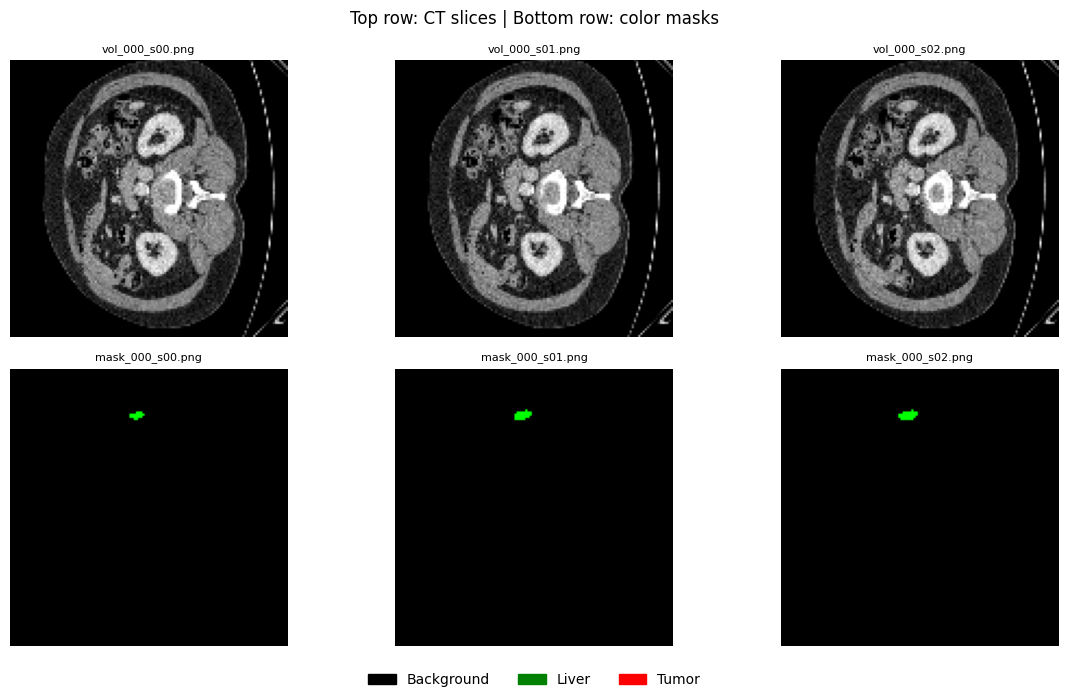

In [8]:
# ══════════════════════════════════════════════════════════════════════
#  EXPORT PROCESSED TRAINING SLICES → PNG
#  Kya save hoga:
#    /kaggle/working/exported_slices/
#      ├── images/   → grayscale CT slices  (vol_000_s00.png)
#      └── masks/    → color-coded masks    (mask_000_s00.png)
#                        black=background, green=liver, red=tumor
# ══════════════════════════════════════════════════════════════════════

import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import gc

EXPORT_DIR = '/kaggle/working/exported_slices'
IMG_DIR    = os.path.join(EXPORT_DIR, 'images')
MASK_DIR   = os.path.join(EXPORT_DIR, 'masks')
os.makedirs(IMG_DIR,  exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

COLOR_MAP = np.array([
    [0,   0,   0],    # 0 — background
    [0,   255, 0],    # 1 — liver
    [255, 0,   0],    # 2 — tumor
], dtype=np.uint8)

def preprocess_slice(vol_slice):
    vol = np.clip(vol_slice, CFG.HU_MIN, CFG.HU_MAX).astype(np.float32)
    return (vol - CFG.HU_MIN) / (CFG.HU_MAX - CFG.HU_MIN)

def resize_slice(arr_2d, size, mode='bilinear'):
    t = torch.from_numpy(arr_2d).unsqueeze(0).unsqueeze(0).float()
    r = F.interpolate(t, size=(size, size),
                      mode=mode,
                      align_corners=False if mode == 'bilinear' else None)
    return r.squeeze().numpy()

# CFG_V2 ho to uske paths, warna CFG fallback
try:
    _vol_dir = Path(CFG_V2.VOLUME_DIR)
    _seg_dir = Path(CFG_V2.SEG_DIR)
    _max_slices = CFG_V2.MAX_SLICES_PER_VOL
    print("📁 Using CFG_V2 paths")
except NameError:
    _vol_dir = Path(CFG.VOLUME_DIR)
    _seg_dir = Path(CFG.SEG_DIR)
    _max_slices = CFG.MAX_SLICES_PER_VOL
    print("📁 Using CFG paths")

vol_paths = sorted(_vol_dir.glob('*.nii')) or sorted(_vol_dir.glob('*.nii.gz'))
seg_paths = sorted(_seg_dir.glob('*.nii')) or sorted(_seg_dir.glob('*.nii.gz'))

pairs = []
for vp in vol_paths:
    vid = ''.join(filter(str.isdigit, vp.stem))
    matched = [sp for sp in seg_paths if ''.join(filter(str.isdigit, sp.stem)) == vid]
    if matched:
        pairs.append((str(vp), str(matched[0])))

print(f"✅ Matched pairs : {len(pairs)}")
print(f"📐 IMG_SIZE      : {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")
print(f"💾 Output        : {EXPORT_DIR}\n")

total_saved = 0

for vol_idx, (vol_path, seg_path) in enumerate(tqdm(pairs, desc='Exporting')):
    vol = nib.load(vol_path).get_fdata().astype(np.float32)
    seg = nib.load(seg_path).get_fdata().astype(np.uint8)

    slice_count = 0
    for s in range(seg.shape[2]):
        if slice_count >= _max_slices:
            break
        seg_s = seg[:, :, s]
        if np.sum(seg_s >= 1) < CFG.MIN_LIVER_PIXELS:
            continue

        vol_norm    = preprocess_slice(vol[:, :, s])
        vol_resized = resize_slice(vol_norm, CFG.IMG_SIZE, mode='bilinear')
        seg_resized = np.round(resize_slice(seg_s.astype(np.float32),
                                            CFG.IMG_SIZE, mode='nearest')).astype(np.uint8)

        vol_uint8 = (vol_resized * 255).clip(0, 255).astype(np.uint8)
        mask_rgb  = COLOR_MAP[np.clip(seg_resized, 0, 2)]

        fname = f"vol_{vol_idx:03d}_s{slice_count:02d}"
        Image.fromarray(vol_uint8, mode='L').save(os.path.join(IMG_DIR,  f"{fname}.png"))
        Image.fromarray(mask_rgb,  mode='RGB').save(os.path.join(MASK_DIR, f"mask_{vol_idx:03d}_s{slice_count:02d}.png"))

        slice_count += 1
        total_saved += 1

    del vol, seg
    gc.collect()

print(f"\n✅ Done! {total_saved} slices saved")
print(f"   Images → {IMG_DIR}")
print(f"   Masks  → {MASK_DIR}")

# Preview — pehli 3 pairs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

imgs  = sorted(os.listdir(IMG_DIR))[:3]
masks = sorted(os.listdir(MASK_DIR))[:3]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Top row: CT slices | Bottom row: color masks', fontsize=12)
for col, (imgf, mskf) in enumerate(zip(imgs, masks)):
    axes[0, col].imshow(np.array(Image.open(os.path.join(IMG_DIR,  imgf))), cmap='gray')
    axes[0, col].set_title(imgf, fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(np.array(Image.open(os.path.join(MASK_DIR, mskf))))
    axes[1, col].set_title(mskf, fontsize=8); axes[1, col].axis('off')
fig.legend(handles=[
    mpatches.Patch(color='black', label='Background'),
    mpatches.Patch(color='green', label='Liver'),
    mpatches.Patch(color='red',   label='Tumor'),
], loc='lower center', ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()